# Unsupervised Learning: Autoencoders. 

---

**Name:** Kahla Maha

---



# Environment setup

Import required modules.

In [ ]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as TF
import torchvision.transforms.functional as TVF
from torch import optim

from torchvision import models, transforms
from torchsummary import summary

import time
import math
import random

from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.metrics import accuracy_score

import seaborn as sns
from matplotlib import colors, pyplot as plt
from matplotlib import rcParams
from IPython.display import clear_output

from tqdm import tqdm

%matplotlib inline
rcParams['figure.figsize'] = (15,4)
sns.set(style="darkgrid", font_scale=1.4)

For reproducibility of the results, fix seed parameter in random number generators.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

The GPU can be used to accelerate training. For convenience, let's create a special variable.

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Let us check that training on GPU is available.

In [ ]:
#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')

Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


<ipython-input-4-479eaf52c20e>:6: FutureWarning: `torch.cuda.memory_cached` has been renamed to `torch.cuda.memory_reserved`
  print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')


# Dataset loading

### From google drive


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
!unzip -q /content/gdrive/MyDrive/segmentation.zip

# Task 1. Data preparation

Let's take a look at the dataset of road photos and prepare it for training if necessary.

In [ ]:
X = np.load('./x_train.npy')

print(X.shape)

(3083, 256, 256, 3)


To make sure everything is correct, we will draw some images

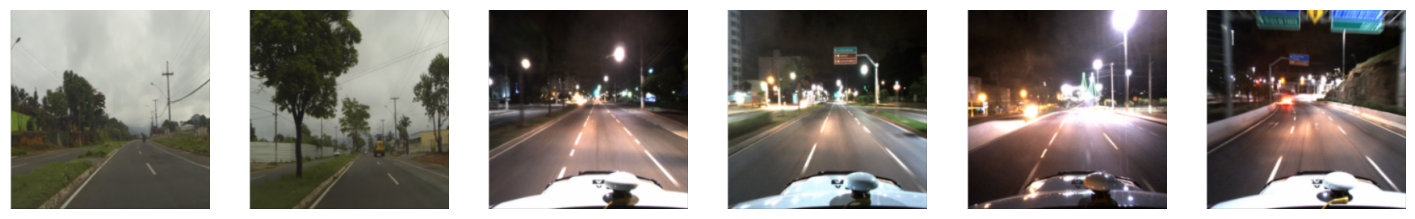

In [ ]:
plt.figure(figsize=(18, 6))
for i in range(6):
    j = 100*i + 1;
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[j])
plt.show();

In [ ]:
XX = np.transpose(X[0:3000:1], axes=(0, 3, 1, 2))
print(XX.shape)

(3000, 3, 256, 256)


In [ ]:
XXX = np.array(XX / 255, dtype='float32')

print(XXX.shape)

(3000, 3, 256, 256)


Downscale images and normalize

In [ ]:
h_new = w_new = 256 // 2
dataset_mean = (0.485, 0.456, 0.406) 
dataset_std = (0.229, 0.224, 0.225) 

In [ ]:
X_t =  torch.FloatTensor(XXX) # resize images and normalize
X_t = transforms.functional.resize(X_t,(128, 128))
for x in X_t:

  transforms.functional.normalize(x, (0.485, 0.456, 0.406), (0.229, 0.224, 0.225), inplace=True)


print(X_t.shape)

torch.Size([3000, 3, 128, 128])


In the following lines of code, we try to free up some memory in order not to have problem of stopping the runtime due to full RAM, so we call the garbage collector to do a collection of all generations.

In [ ]:
import gc

X = 0
XX = 0
XXX = 0
gc.collect()

8796

Let's divide 3000 pictures by 2500/500 for training, validation respectively.

In [ ]:
ix = np.random.choice(len(X_t), len(X_t), False)
tr, val = np.split(ix, [2500])

Create dataloaders

In [ ]:
X_train_t = X_t[tr]
X_val_t = X_t[val]

train_dataset = TensorDataset(X_train_t, X_train_t)
val_dataset = TensorDataset(X_val_t, X_val_t)

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [ ]:
loaders = {"train": train_dataloader, "valid": val_dataloader}

-----

Below is a function for displaying pictures that have been normalized and stored in tensors.

In [ ]:
"""Inverse transform to obtain denormalized image from tensor with correct channels"""
def tensor2image(inp):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = dataset_std * inp + dataset_mean
    inp = np.clip(inp, 0, 1)

    return inp

In [ ]:
"""Custom Imshow for tensors"""
def imshow(inp, title=None, plt_ax=plt, default=False):
    plt_ax.imshow(tensor2image(inp))
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

Display one of the pictures after normalization to make sure all is correct

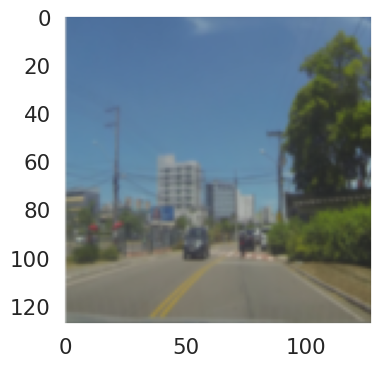

In [ ]:
item = next(iter(train_dataloader))[0]
imshow(item[0])

# Task 2. Create Autoencoder

In [ ]:
class SimpleAutoencoder(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()
        self.latent_channels = latent_channels

        # REQUIREMENT: The number of elements in the encoder output must be 16,384 when latent_channels = 64
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16 , kernel_size = 3, stride = 2 , padding = 1),
            nn.ReLU(),
            nn.Conv2d(16 ,32 , 3, stride = 2 , padding = 1),
            nn.ReLU(),
            nn.Conv2d(32, latent_channels , 3, stride = 2, padding = 1),
            nn.ReLU(),


        )

        self.decoder = nn.Sequential(
            # Use nn.ConvTranspose2d and nn.ReLU blocks
            nn.ConvTranspose2d(latent_channels, 32 , kernel_size = 3, stride = 2 , padding = 1 , output_padding = 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16 , kernel_size = 3, stride = 2 , padding = 1 , output_padding = 1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3 , kernel_size = 3, stride = 2 , padding = 1 , output_padding = 1),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


We don't use activation after the last layer in order to have the output values unbounded, and we want the resulted images to be symmetrically constructed as the input images are normalized. Also we will use nn.MSELoss(), so we don't necessarily need to restrict outputs.

# Task 2. Training

In [ ]:
def plot_example(X_batch, Y_pred, title):
    clear_output(wait=True)

    plt.rcParams["figure.figsize"] = (18,6)
    for k in range(6):
        plt.subplot(2, 6, k+1)
        plt.imshow(tensor2image(X_batch[k]))
        plt.title('Photo')
        plt.axis('off')

        if Y_pred != None:
            plt.subplot(2, 6, k+7)
            plt.imshow(tensor2image(Y_pred[k]))
            plt.title('Reconstructed')
            plt.axis('off')

    plt.suptitle(title)

    figure_name = title.split(',')[0]
    plt.savefig(f"{figure_name}.png")
    plt.show()

In [ ]:
import time
def save_model_wh(name, model):
    ts = time.time()
    path = '/content/gdrive/MyDrive/' + str(ts) + "_" + name + ".mw"
    torch.save(model.state_dict(), path)

In [ ]:
def train(name, model, optimizer, loss_fn, epochs, loaders, scheduler = None, save_params = False):
    losses = {"train": [], "valid": []}


    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None


    for epoch in range(epochs):
        print('* Epoch %d/%d' % (epoch+1, epochs))

        for stage, dataloader in loaders.items():
            avg_loss = 0

            if stage == 'train':
                model.train()
            else:
                model.eval()

            for X_batch, Y_batch in dataloader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)

                if stage == 'train':
                    optimizer.zero_grad()
                    logits = model(X_batch)
                    loss = loss_fn(logits, Y_batch)
                    loss.backward()
                    optimizer.step()
                else:
                    with torch.no_grad():
                        logits = model(X_batch)
                        loss = loss_fn(logits, Y_batch)

                # calculate score and loss to show the user
                Y_pred = logits.detach()

                avg_loss += loss.detach().cpu().numpy() / len(dataloader)

                # clean GPU memory
                X_batch = X_batch.cpu()
                Y_batch = Y_batch.cpu()
                logits = logits.cpu()
                Y_pred = Y_pred.cpu()
                torch.cuda.empty_cache()

            losses[stage].append(avg_loss)

        if stage == 'valid':
            if save_params:
                save_model_wh(name, model)

            if (epoch + 1) % 2 == 0:
                if scheduler != None:
                    plot_example(X_batch, Y_pred, f"epoch {epoch+1} from {epochs}, avg_loss={avg_loss}, lr={scheduler.get_last_lr()[0]}")
                else:
                    plot_example(X_batch, Y_pred, f"epoch {epoch+1} from {epochs}, avg_loss={avg_loss}")
            else:
                if scheduler != None:
                    print(f"epoch {epoch+1}/{epochs}, avg_loss={avg_loss}, lr={scheduler.get_last_lr()[0]}")
                else:
                    print(f"epoch {epoch+1}/{epochs}, avg_loss={avg_loss}")

        val_loss = losses["valid"][-1]
        if scheduler != None:
            scheduler.step(val_loss)

        
        if val_loss < best_val_loss - 1e-5:
            epochs_no_improve = 0
        
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
        


    return losses

Train your model

In [ ]:
def plot_losses(losses):
    # fig, axs = plt.subplots(1, 1, constrained_layout=True)
    # flat_axs = axs.flatten()

    plt.plot(range(len(losses['train'])), losses['train'], label="Train", linewidth=2)
    plt.plot(range(len(losses['valid'])), losses['valid'], label="Validation", linewidth=2)
    plt.legend()
    plt.xlabel("Epoch")

    plt.show()

In [ ]:
model64 = SimpleAutoencoder(latent_channels=64).to(device)# create model with latent_channels=64
optimizer = torch.optim.Adam(model64.parameters(), lr=0.01)
criterion = nn.MSELoss()

In [ ]:
#  [OPTIONAL] scheduler
# from torch.optim.lr_scheduler import

#  [OPTIONAL] early stopping
early_stopping_patience = 10
epochs_no_improve = 0

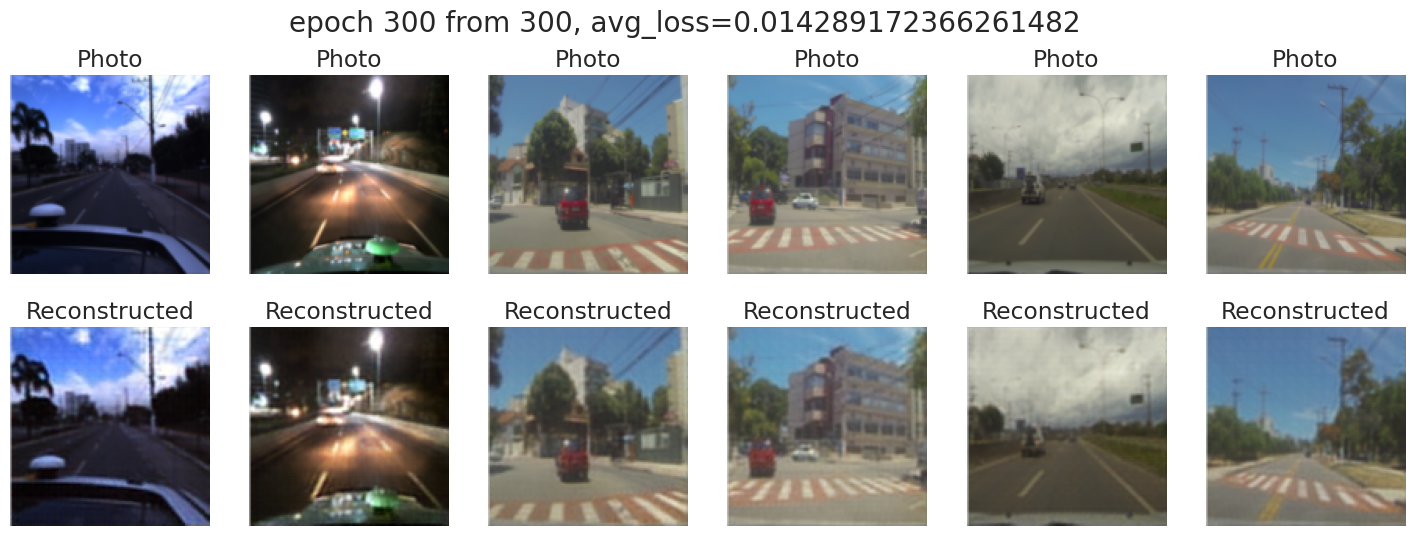

In [ ]:
losses1 = train('MODEL64', model64, optimizer, criterion, 300, loaders, scheduler = None, save_params = True) # TODO train

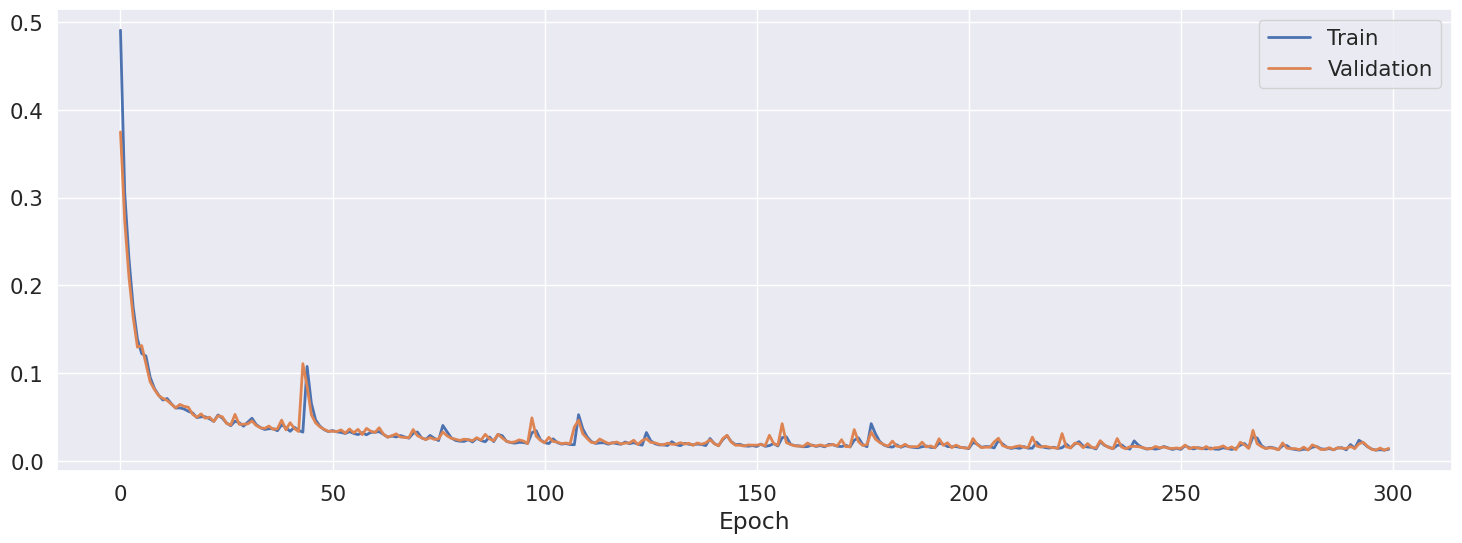

In [ ]:
plot_losses(losses1)

Show the intermediate steps of the learning process.

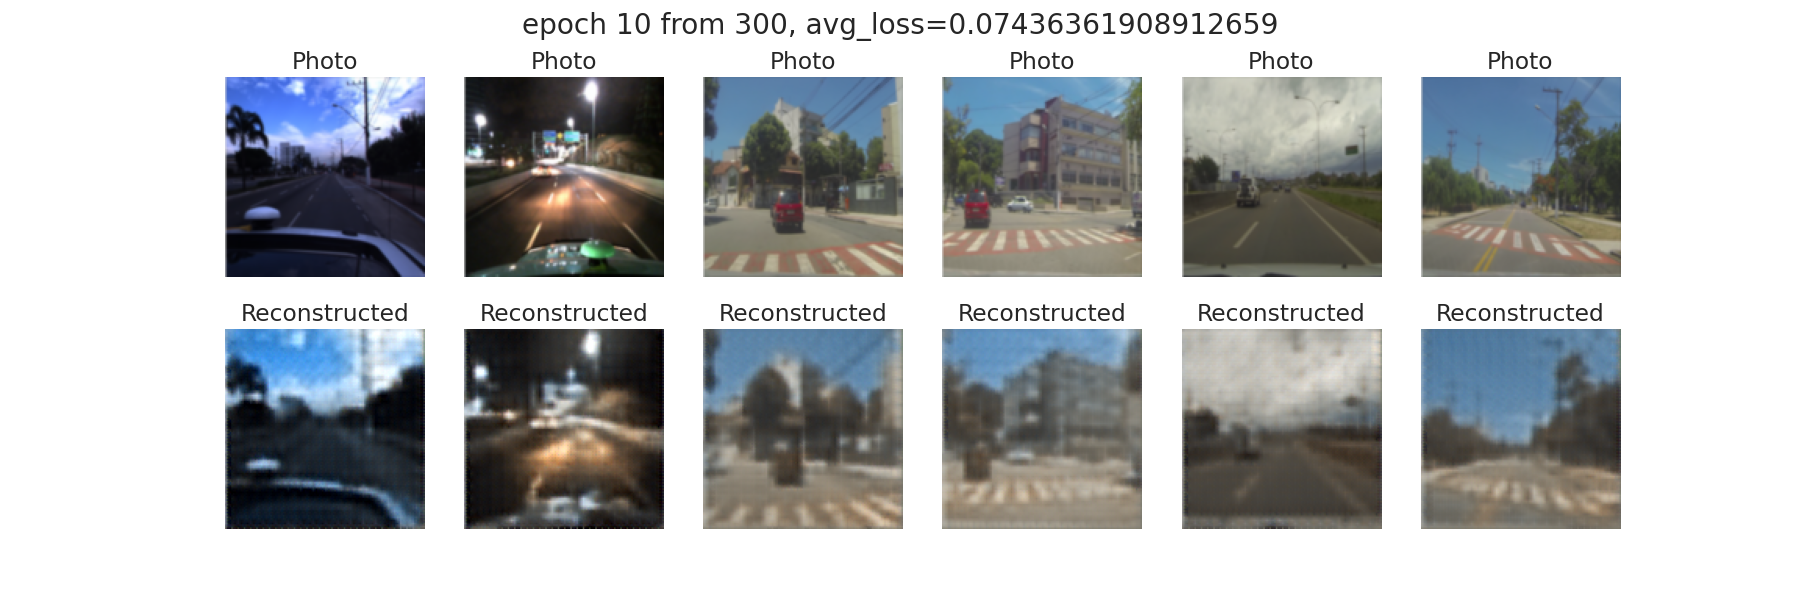

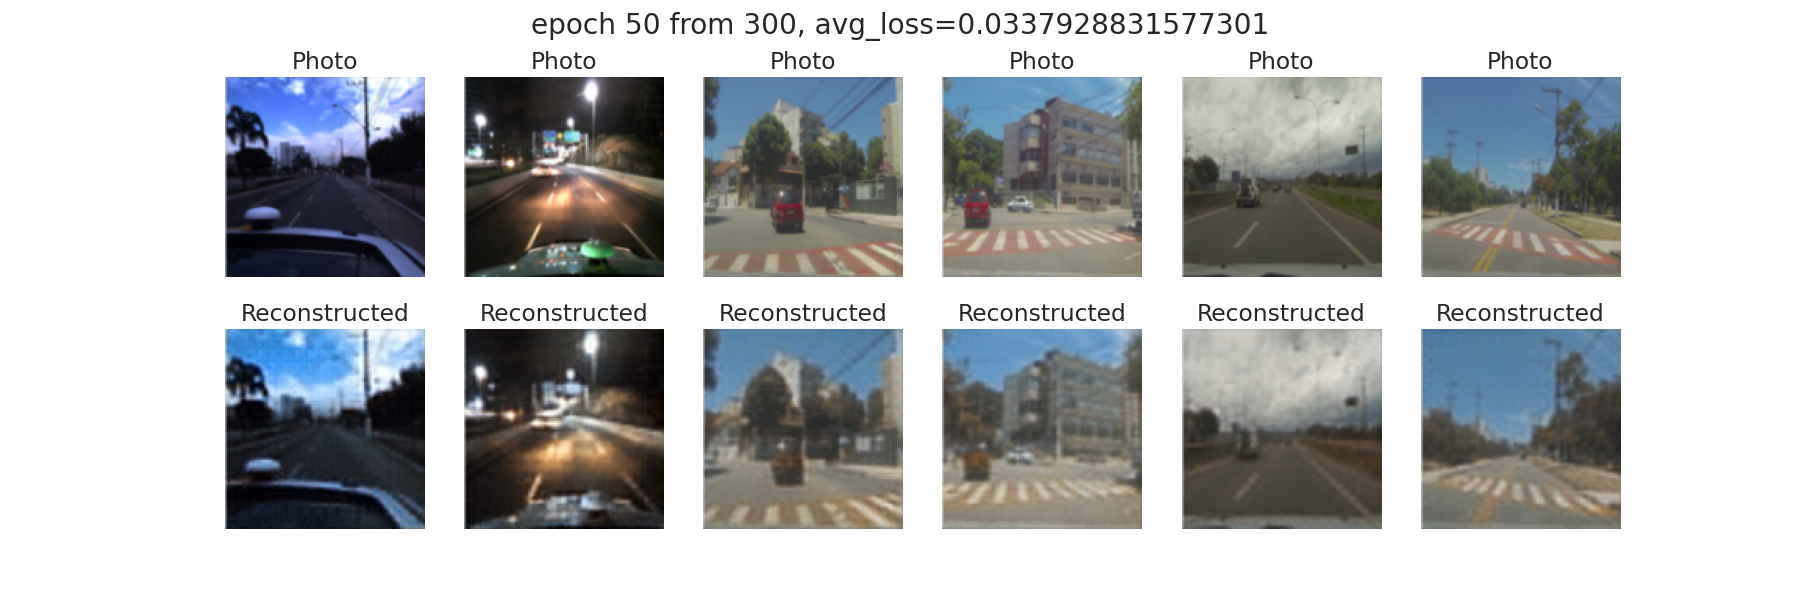

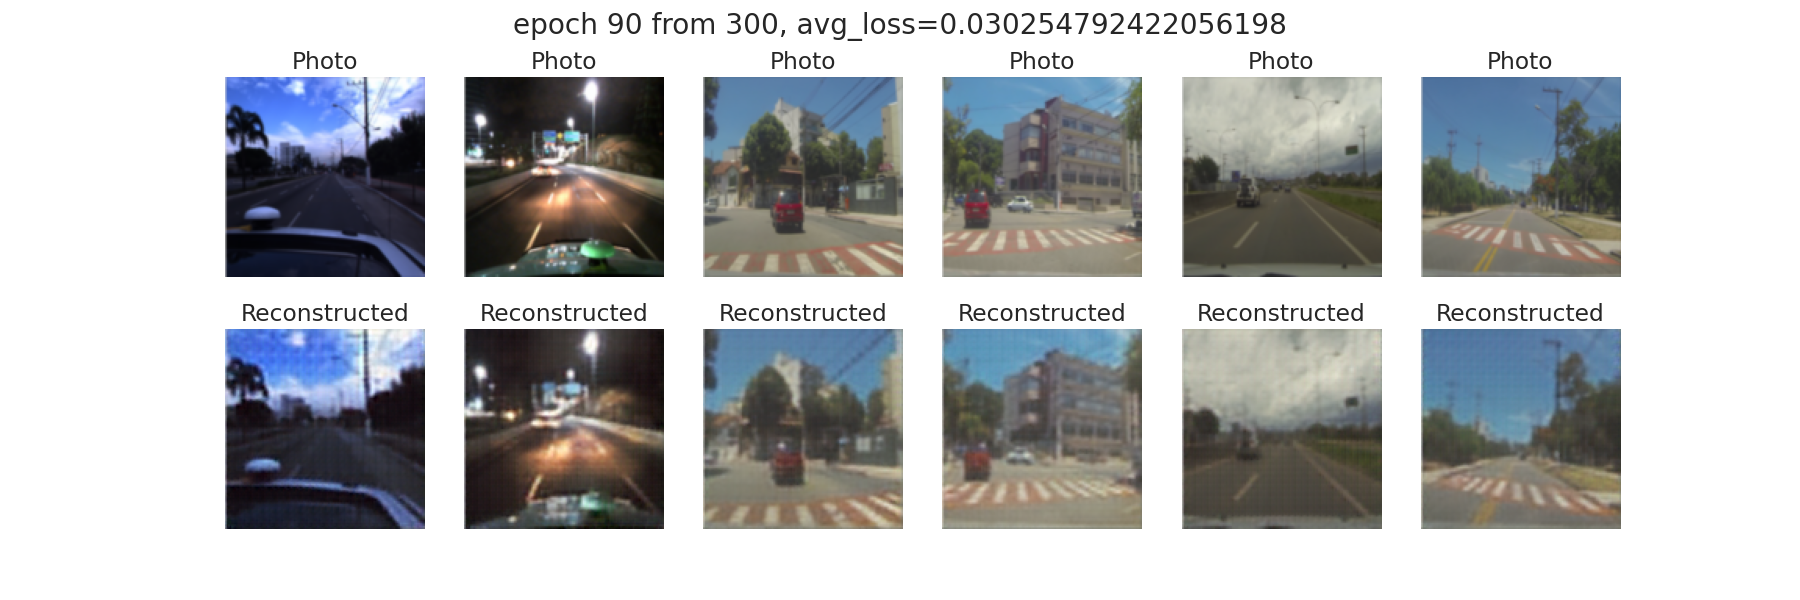

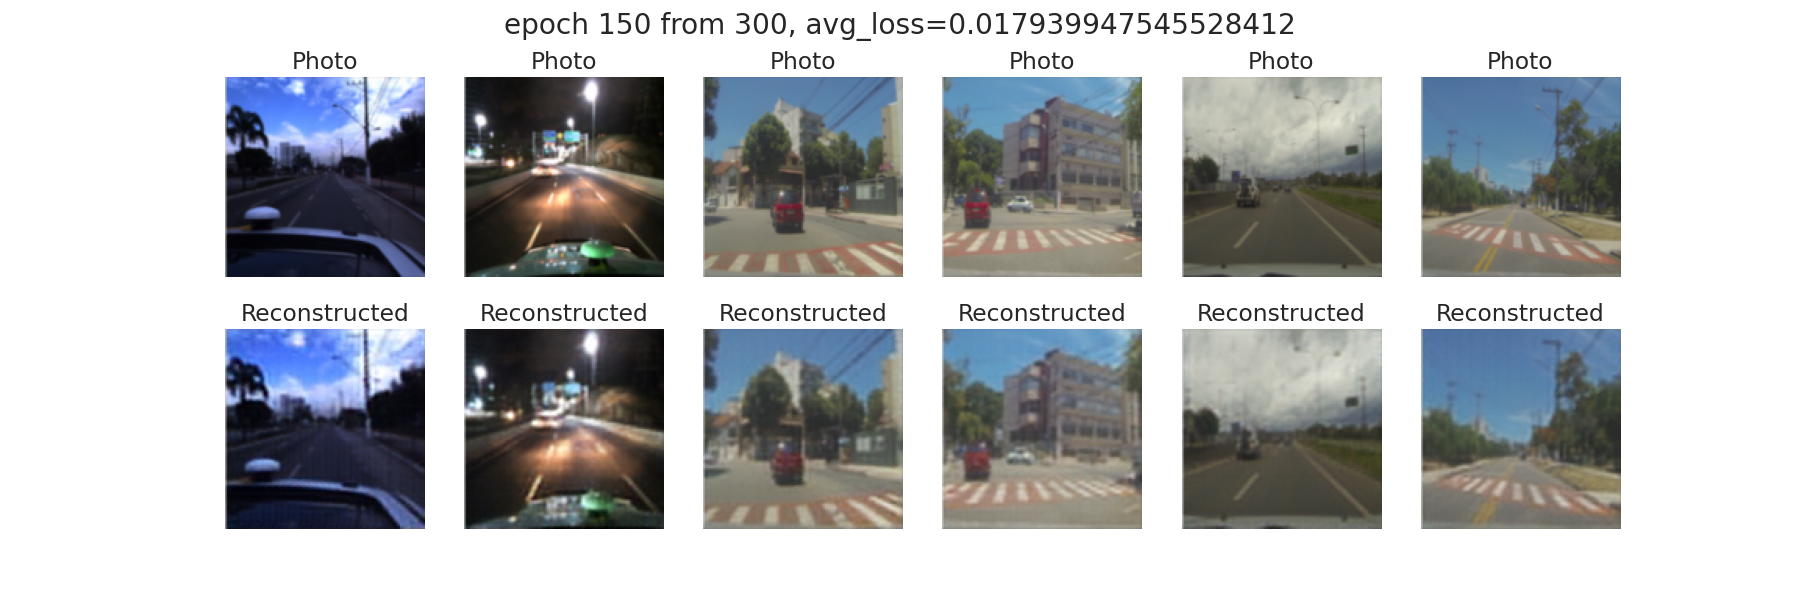

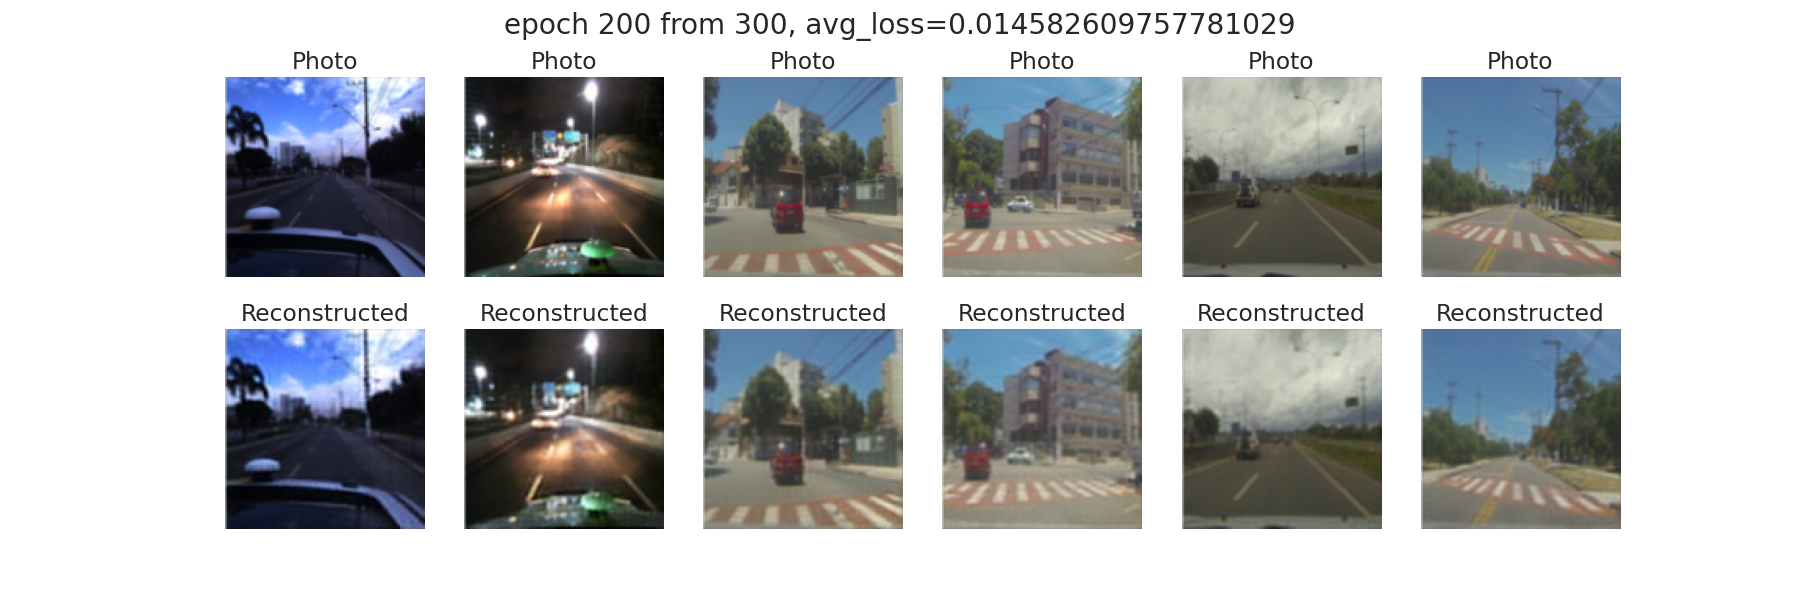

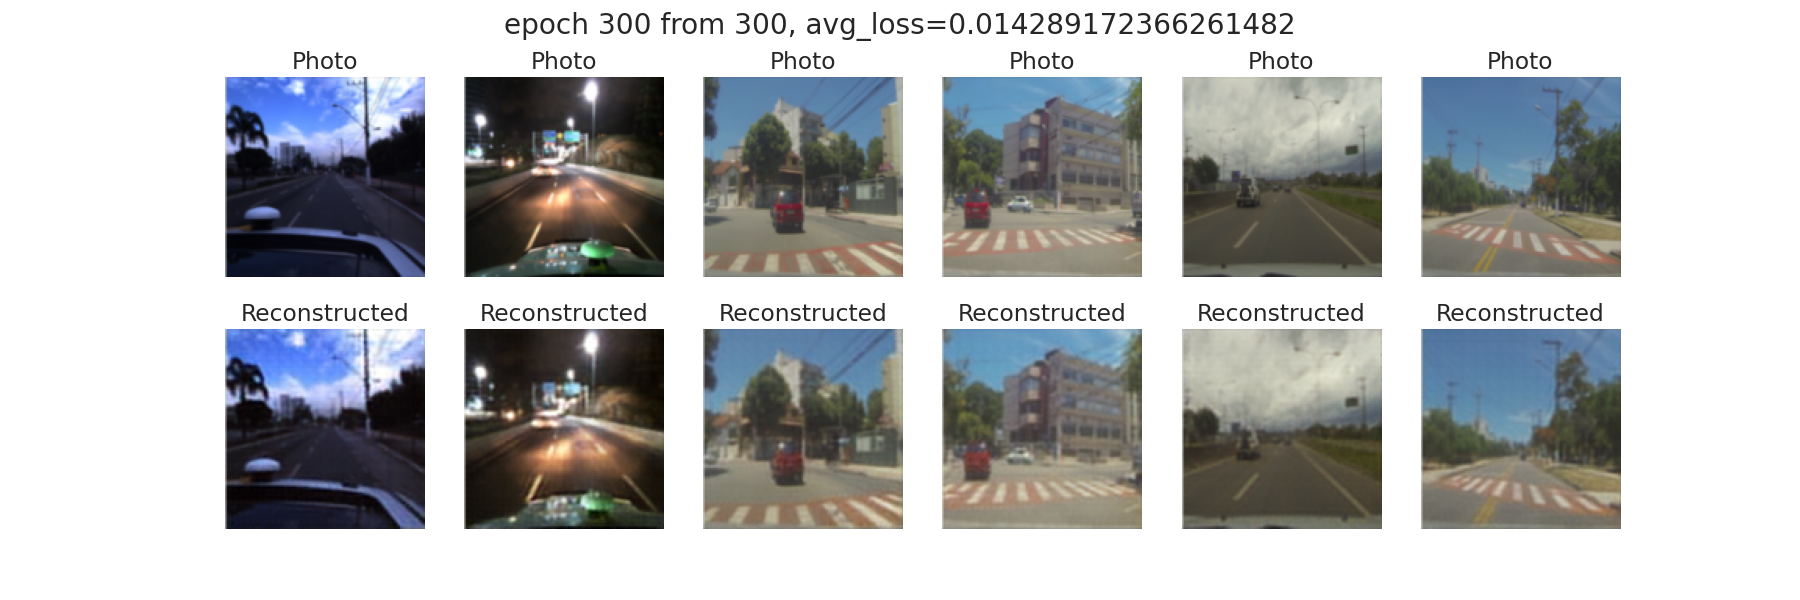

In [ ]:
from IPython.display import Image, display


# REQUIREMENT: At least 50 epochs must be taken into account
filenames = [
    "epoch 10 from 300.png",
    "epoch 50 from 300.png",
    "epoch 90 from 300.png",
    "epoch 150 from 300.png",
    "epoch 200 from 300.png",
    "epoch 300 from 300.png",
]

for name in filenames:
    display(Image(filename=name))



Obviously, we can notice that the loss decreases steadily from and the visual quality of reconstructions improves significantly over time. After the first ten epochs the reconstructions are very blurry, lacking detail and color fidelity, and we barely can recognize the shapes. After 50 epochs more stuctures can be captured like the buildings. After 150 epochs the images became more detailed and color-accurate. After 200 epochs, we got a sharp reconstrucions and the object outlines are very close to the original.

# Task 3. Enhance quality

 Repeat training until the loss is less than or equal to 0.01.

In [ ]:
model2 = SimpleAutoencoder(latent_channels=64).to(device)
model2.load_state_dict(torch.load('/content/gdrive/MyDrive/1744433175.5057905_M64901.mw', weights_only=True))
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)
criterion = nn.MSELoss()

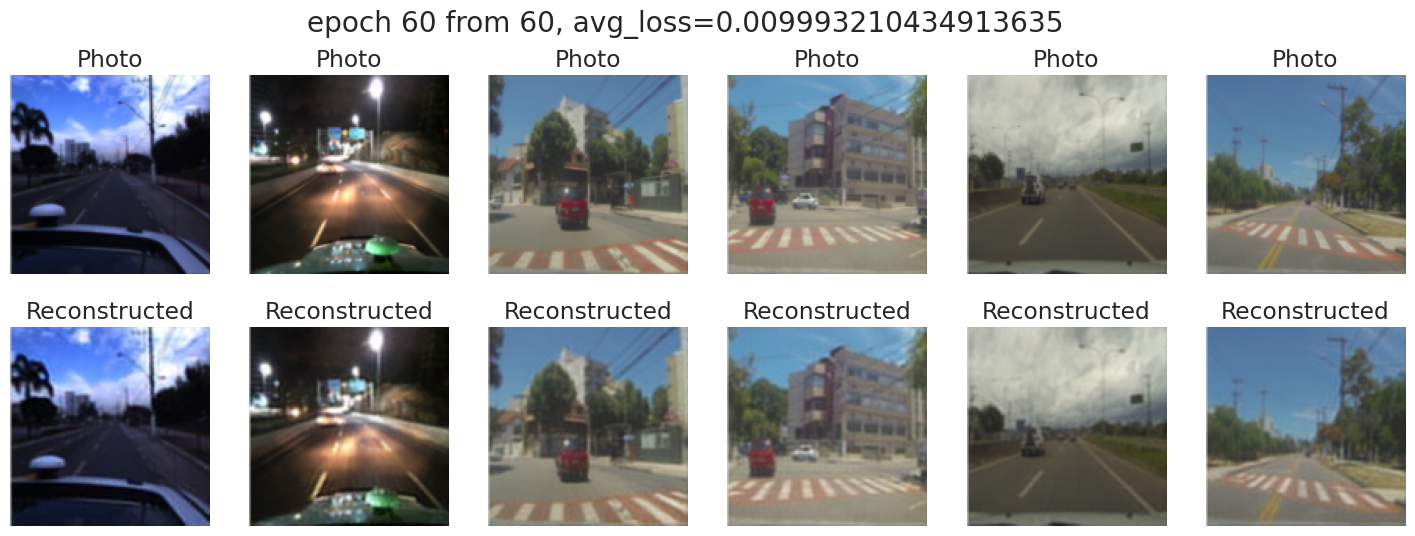

In [ ]:
losses2 = train('Enhance_quality', model2, optimizer, criterion, 60, loaders, scheduler = None, save_params = True) # train

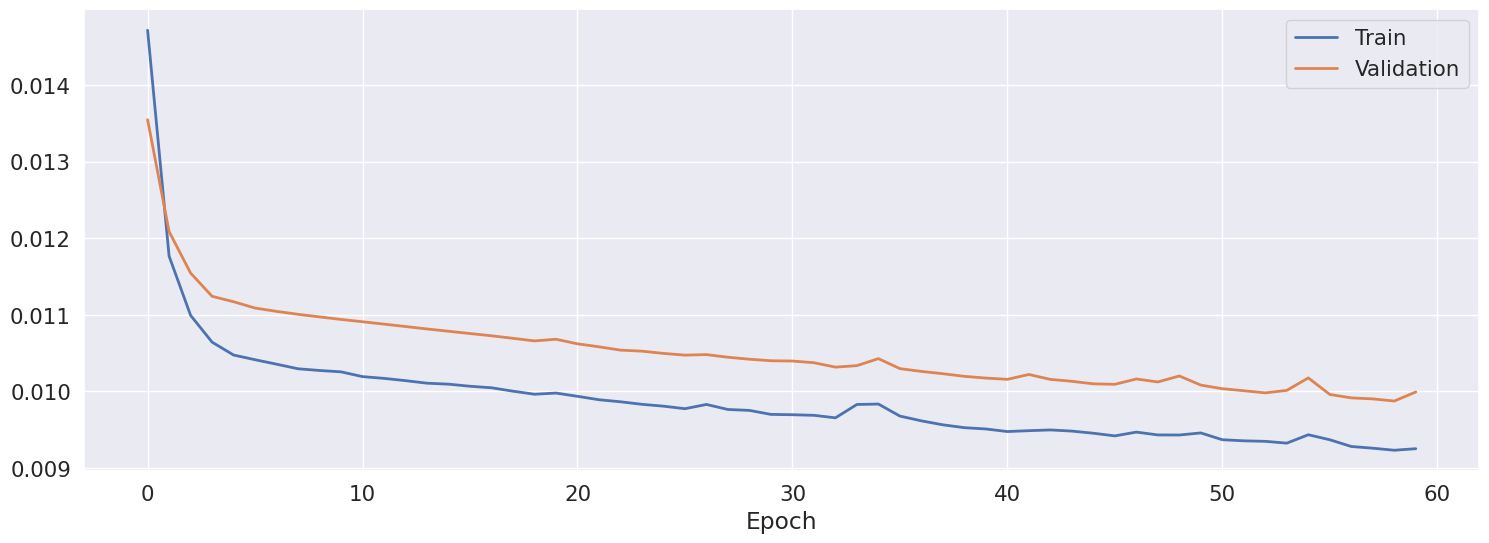

In [ ]:
plot_losses(losses2)

In [ ]:
### 1744462821.0066183_Enhance_quality.mw

In [ ]:
model64 = SimpleAutoencoder(latent_channels=64).to(device)
model64.load_state_dict(torch.load('/content/gdrive/MyDrive/1744462821.0066183_Enhance_quality.mw', weights_only=True))

<All keys matched successfully>

# Task 4. Find Clusters



In [ ]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

In [ ]:
features = []

model64.eval()
with torch.no_grad():
    for x, _ in val_dataloader:
        
        latent_features = model64.encoder(x.to(device))
        latent_features = latent_features.view(x.size(0), -1).cpu()
        features.append(latent_features)
        x = x.cpu()

features = torch.cat(features)

In [ ]:
#  use TSNE with n_components=2, perplexity=30 and fix random_state = 42
tsne = TSNE (n_components=2, perplexity=30 , random_state = 42)
features_2d = tsne.fit_transform(features) 

In [ ]:
#  use KMeans to find 6 clustets + fix random_state
n_clusters = 6
kmeans = KMeans(n_clusters , random_state = 42) 
kmeans.fit(features)
cluster_labels = kmeans.predict(features) 

Plot t-SNE figure

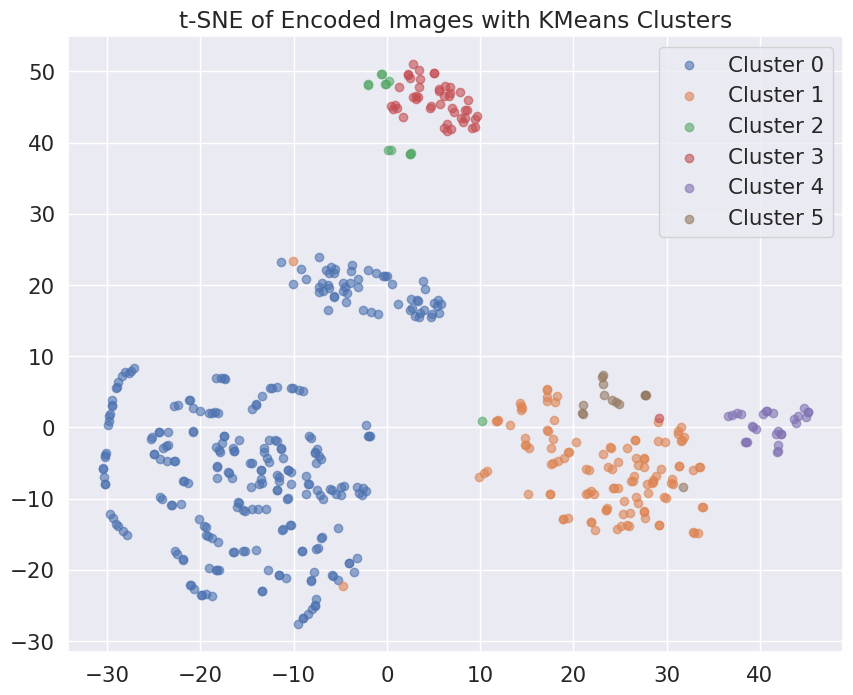

In [ ]:
# Отображение t-SNE
plt.figure(figsize=(10, 8))
for i in range(n_clusters):
    idxs = np.where(cluster_labels == i)
    plt.scatter(features_2d[idxs, 0], features_2d[idxs, 1], label=f'Cluster {i}', alpha=0.6)
plt.legend()
plt.title("t-SNE of Encoded Images with KMeans Clusters")
plt.show()

Show 5 random images from each cluster

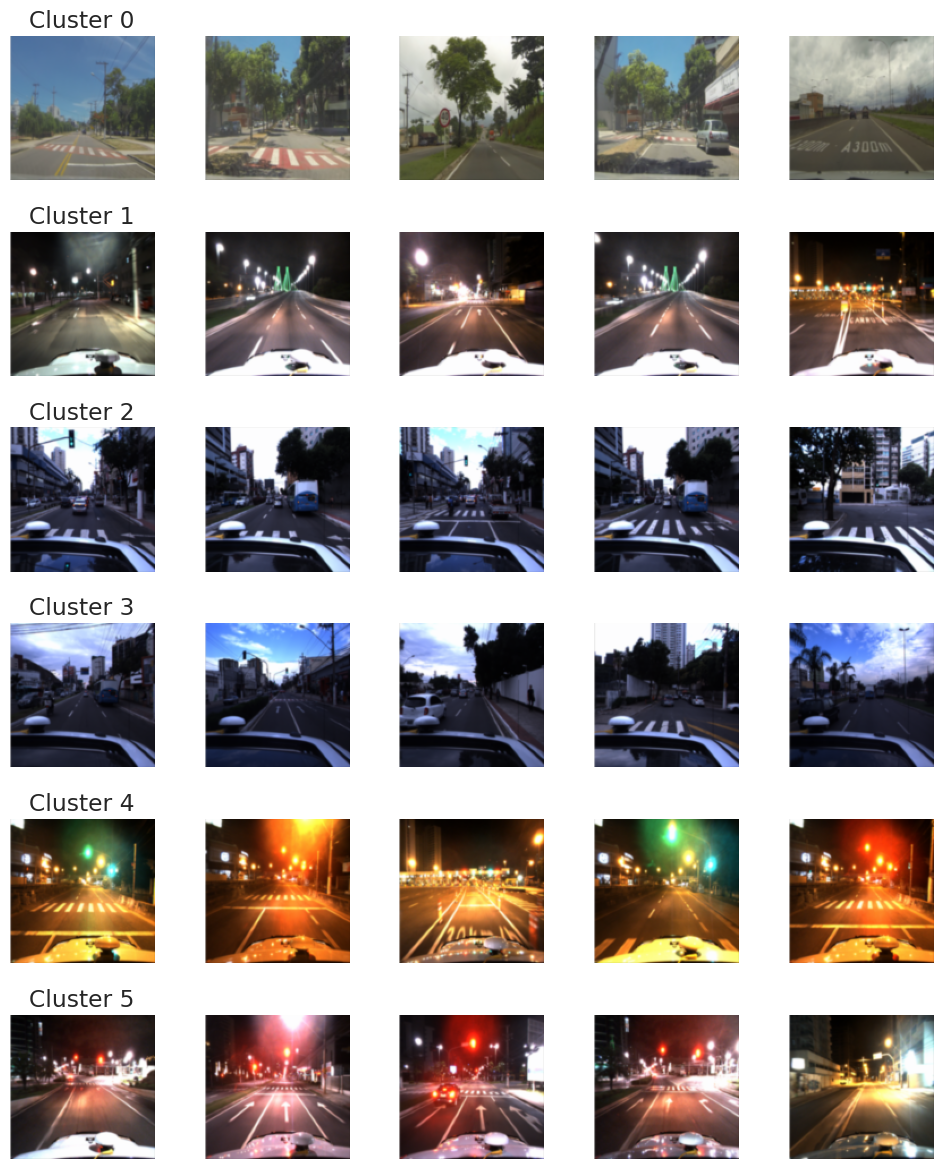

In [ ]:

samples_per_cluster = 5
fig, axes = plt.subplots(n_clusters, samples_per_cluster, figsize=(samples_per_cluster*2, n_clusters*2))

for cluster in range(n_clusters):
    cluster_indices = np.where(cluster_labels == cluster)[0][:samples_per_cluster]
    for i, idx in enumerate(cluster_indices):
        ax = axes[cluster, i]
        ax.imshow(tensor2image(X_val_t[idx]))
        ax.axis('off')

    axes[cluster, 0].set_title(f'Cluster {cluster}')

plt.tight_layout()
plt.show()




In cluster 0 , clear skies, green and open views and day light.

In cluster 1, roads are open and wide with low traffic, road lamps.

In cluster 2, lots of buildings, traffic lights and cars. Pedestrian crossings and daylight.

In cluster 3, the sky, and the environment is less bright than cluster 2.

In cluster 4, traffic lights are prominent and the surrounding is dark.

In cluster 5, the red light, and some buildings are lit more than in cluster 4.